<a href="https://colab.research.google.com/github/adas754/computer_vision/blob/main/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASHION MNIST

In [14]:
# Import Libraries
# Import Libraries

import numpy as np
# Used for numerical calculations and working with arrays.

import matplotlib.pyplot as plt
# Used to display images and create graphs.

import seaborn as sns
# Used to create attractive statistical graphs, such as heatmaps.

import tensorflow as tf
# Main deep-learning library used to build and train the CNN.

import cv2
# OpenCV library, used for image processing.

from tensorflow.keras.datasets import fashion_mnist
# Loads the Fashion-MNIST dataset (clothes, shoes, bags, etc.).

from tensorflow.keras.models import Sequential
# Creates a neural network layer-by-layer.

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# Conv2D → extracts features from images.
# MaxPooling2D → reduces image size.
# Flatten → converts feature maps into a 1D array.
# Dense → fully connected neural-network layer.
# Dropout → randomly turns off some neurons to reduce overfitting.

from tensorflow.keras.callbacks import EarlyStopping
# Stops training early when the model stops improving.

from sklearn.metrics import confusion_matrix, classification_report
# confusion_matrix → shows correct and incorrect predictions.
# classification_report → gives precision, recall, F1-score, and accuracy.

In [15]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)


In [17]:
# Check unique label values and their counts

unique_labels, counts = np.unique(y_train, return_counts=True)
# Finds each different label in y_train and counts how many times each label appears.

print("Unique labels:", unique_labels)
# Prints the unique labels, e.g. [0 1 2 3 4 5 6 7 8 9].

for lab, cnt in zip(unique_labels, counts):
    # Goes through each label and its corresponding count.

    print(f"Label {lab}: {cnt} samples")
    # Prints how many training images belong to each label.


Unique labels: [0 1 2 3 4 5 6 7 8 9]
Label 0: 6000 samples
Label 1: 6000 samples
Label 2: 6000 samples
Label 3: 6000 samples
Label 4: 6000 samples
Label 5: 6000 samples
Label 6: 6000 samples
Label 7: 6000 samples
Label 8: 6000 samples
Label 9: 6000 samples




 This checks **which classes are present** and **how many images belong to each class**.


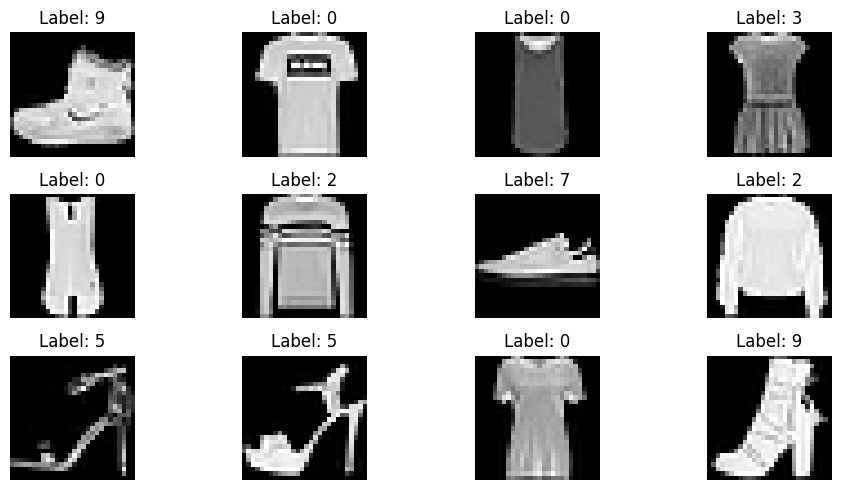

In [18]:
# ============================================================
# 5. Visualize Sample Images (numeric labels only)
# ============================================================

plt.figure(figsize=(10,5))
# Creates a figure with size 10×5.

for i in range(12):
    # Repeats the following steps for the first 12 images.

    plt.subplot(3,4,i+1)
    # Creates a grid of 3 rows × 4 columns.
    # i+1 selects the current position (1 to 12).

    plt.imshow(x_train[i], cmap="gray")
    # Displays the i-th training image in grayscale.

    plt.title(f"Label: {y_train[i]}")
    # Displays the correct label of that image.

    plt.axis('off')
    # Hides the x and y axes.

plt.tight_layout()
# Adjusts spacing so the images and titles don't overlap.

plt.show()
# Displays all 12 images.

In [5]:
# ============================================================
# 4. Define Class Names AFTER Checking Dataset Labels
# ============================================================

class_names = [
    "T-shirt/top",   # 0
    "Trouser",       # 1
    "Pullover",      # 2
    "Dress",         # 3
    "Coat",          # 4
    "Sandal",        # 5
    "Shirt",         # 6
    "Sneaker",       # 7
    "Bag",           # 8
    "Ankle boot"     # 9
]


In [19]:
# ============================================================
# 6. Preprocessing
#     - Normalize pixel values (0–255 → 0–1)
#     - Reshape images for CNN (28×28 → 28×28×1)
# ============================================================

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New shape:", x_train.shape, x_test.shape)


New shape: (60000, 28, 28, 1) (10000, 28, 28, 1)


In [20]:
# ============================================================
# 7. Build the CNN Model
# ============================================================

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ============================================================
# 8. Compile the Model
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [22]:
# ============================================================
# 9. Train the CNN Model
# ============================================================

history = model.fit(
    x_train, y_train,
    epochs=8,
    validation_split=0.3
)


Epoch 1/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8263 - loss: 0.4821 - val_accuracy: 0.8746 - val_loss: 0.3433
Epoch 2/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8826 - loss: 0.3190 - val_accuracy: 0.8870 - val_loss: 0.3079
Epoch 3/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9002 - loss: 0.2723 - val_accuracy: 0.8974 - val_loss: 0.2785
Epoch 4/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9125 - loss: 0.2368 - val_accuracy: 0.8920 - val_loss: 0.2919
Epoch 5/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9205 - loss: 0.2125 - val_accuracy: 0.9048 - val_loss: 0.2565
Epoch 6/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9299 - loss: 0.1885 - val_accuracy: 0.9106 - val_loss: 0.2476
Epoch 7/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9375 - loss: 0.1668 - val_accuracy: 0.9137 - val_loss: 0.2570
Epoch 8/8
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9450 - loss: 0.1472 - val_acc

In [23]:
# ============================================================
# 10. Evaluate on Test Data
# ============================================================

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9041 - loss: 0.2856
Test Loss : 0.2855501174926758
Test Accuracy : 0.9041000008583069


In [24]:
import numpy as np
from tensorflow.keras.preprocessing import image

# class names for Fashion MNIST
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# get uploaded file name
file_name = "/content/images (2).jfif"   # change this path


# read the image using cv2
img = cv2.imread(file_name)

# convert to gray (Fashion MNIST training was grayscale)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize to 28×28
img_resized = cv2.resize(img_gray, (28, 28))

# normalize
img_normalized = img_resized / 255.0

# expand dims for model input (1, 28, 28)
img_input = np.expand_dims(img_normalized, axis=0)

# expand channel dimension if model expects (28,28,1)
img_input = np.expand_dims(img_input, axis=-1)


In [26]:
# predict
prediction = model.predict(img_input)
predicted_class = np.argmax(prediction)

print("Predicted Class:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Class: Bag


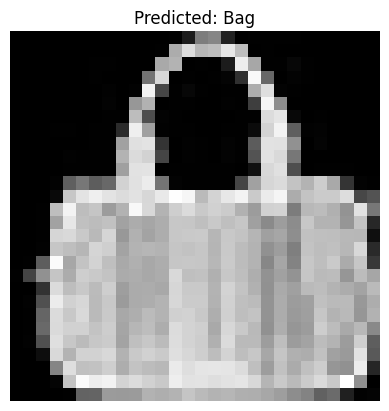

In [27]:
# visualize
plt.imshow(img_resized, cmap='gray')
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis('off')
plt.show()